In [45]:
# 삼성전가 주가 예측 (LSTM)

!pip install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

In [46]:
df = yf.download(
    "005930.KS",
    start = "2018-01-01",
    end = "2026-07-01",
    auto_adjust=True
)

df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2026-06-24,340500.0,341000.0,314000.0,314000.0,47809959
2026-06-25,358500.0,362500.0,352000.0,359500.0,36157158
2026-06-26,339500.0,356500.0,321500.0,354000.0,39735951
2026-06-29,323000.0,335500.0,316000.0,331000.0,35436521
2026-06-30,334000.0,343000.0,321000.0,323500.0,29237216


In [47]:
close = df[["Close"]]

close.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2080 entries, 2018-01-02 to 2026-06-30
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, 005930.KS)  2080 non-null   float64
dtypes: float64(1)
memory usage: 32.5 KB


In [48]:
# 정규화

# 최소값 = 100
# 최대값 = 190

# 현재값 - 100
# ------------
#   190 - 100

scaler = MinMaxScaler()  # 그동안 StandardScaler을 사용했는데 MinMaxscaler은 데이터의 최소값을 0, 최대값을 1로 변환하여 모든 값을 0~1 범위로 맞춤
scaled = scaler.fit_transform(close)

scaled

array([[0.03016287],
       [0.03162562],
       [0.03030917],
       ...,
       [0.9305737 ],
       [0.88076788],
       [0.91397176]])

In [49]:
# 시계열 데이터 생성
# 60일 데이터 분석 => 다음날 예측

# data_size = -1
# time_steps = 60 
# features = 1

window_size = 60

x = []
y = []

for i in range(window_size,len(scaled)) :
    x.append(scaled[i - window_size : i])
    y.append(scaled[i])
    print(window_size,i)

x = np.array(x)
y = np.array(y)

print(x.shape,y.shape)  # (2020, 60, 1) (2020, 1)

60 60
60 61
60 62
60 63
60 64
60 65
60 66
60 67
60 68
60 69
60 70
60 71
60 72
60 73
60 74
60 75
60 76
60 77
60 78
60 79
60 80
60 81
60 82
60 83
60 84
60 85
60 86
60 87
60 88
60 89
60 90
60 91
60 92
60 93
60 94
60 95
60 96
60 97
60 98
60 99
60 100
60 101
60 102
60 103
60 104
60 105
60 106
60 107
60 108
60 109
60 110
60 111
60 112
60 113
60 114
60 115
60 116
60 117
60 118
60 119
60 120
60 121
60 122
60 123
60 124
60 125
60 126
60 127
60 128
60 129
60 130
60 131
60 132
60 133
60 134
60 135
60 136
60 137
60 138
60 139
60 140
60 141
60 142
60 143
60 144
60 145
60 146
60 147
60 148
60 149
60 150
60 151
60 152
60 153
60 154
60 155
60 156
60 157
60 158
60 159
60 160
60 161
60 162
60 163
60 164
60 165
60 166
60 167
60 168
60 169
60 170
60 171
60 172
60 173
60 174
60 175
60 176
60 177
60 178
60 179
60 180
60 181
60 182
60 183
60 184
60 185
60 186
60 187
60 188
60 189
60 190
60 191
60 192
60 193
60 194
60 195
60 196
60 197
60 198
60 199
60 200
60 201
60 202
60 203
60 204
60 205
60 206
60 207
60 2

In [50]:
# train / test 데이터 나누기

train_size = int(len(x) * 0.8)
train_size

x_train = x[:train_size]
x_test = x[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(x_train.shape)
print(x_test.shape)


(1616, 60, 1)
(404, 60, 1)


In [51]:
# 모델링

# model = Sequential([
#     Input(shape=(window_size,1)),
#     SimpleRNN(64,return_sequences=True),
#     SimpleRNN(32),
#     Dense(16,activation="relu"),
#     Dense(1)
# ])

model = Sequential([
    Input(shape=(window_size,1)),  # 중간에 테스트 중 행 개수가 달라질 수 있으니 window_size로 적고 해당 값을 변경하여 조율을 함
    LSTM(64,return_sequences=True),
    LSTM(32),
    Dense(16,activation="relu"),
    Dense(1)
])

model.summary()

model.compile(
    optimizer="adam",
    loss="mse",  
    metrics=["mae"]  # 평균 절대 오차 , 선형회귀이기 때문에 accuracy 아님
)

# EarlyStopping
es = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# 학습

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[es]
)

# 예측

pred = model.predict(x_test)

# 원래 가격 복원

pred_price = scaler.inverse_transform(pred)
real_price = scaler.inverse_transform(y_test)



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 0.0014 - mae: 0.0287 - val_loss: 1.7106e-04 - val_mae: 0.0103
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 9.2882e-05 - mae: 0.0072 - val_loss: 1.2354e-04 - val_mae: 0.0082
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 6.1544e-05 - mae: 0.0057 - val_loss: 1.3530e-04 - val_mae: 0.0090
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 5.5916e-05 - mae: 0.0055 - val_loss: 9.9307e-05 - val_mae: 0.0074
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 5.0366e-05 - mae: 0.0053 - val_loss: 9.1729e-05 - val_mae: 0.0071
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 5.0536e-05 - mae: 0.0053 - val_loss: 1.1124e-04 - val_mae: 0.0083
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 4.7025e-05 - mae: 0.0052 - val_loss: 7.9114e-05 - val_mae: 0.0066
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 4.1759e-05 - mae: 0.0048 - val_loss: 7.8480e-05 - val_mae: 0.0

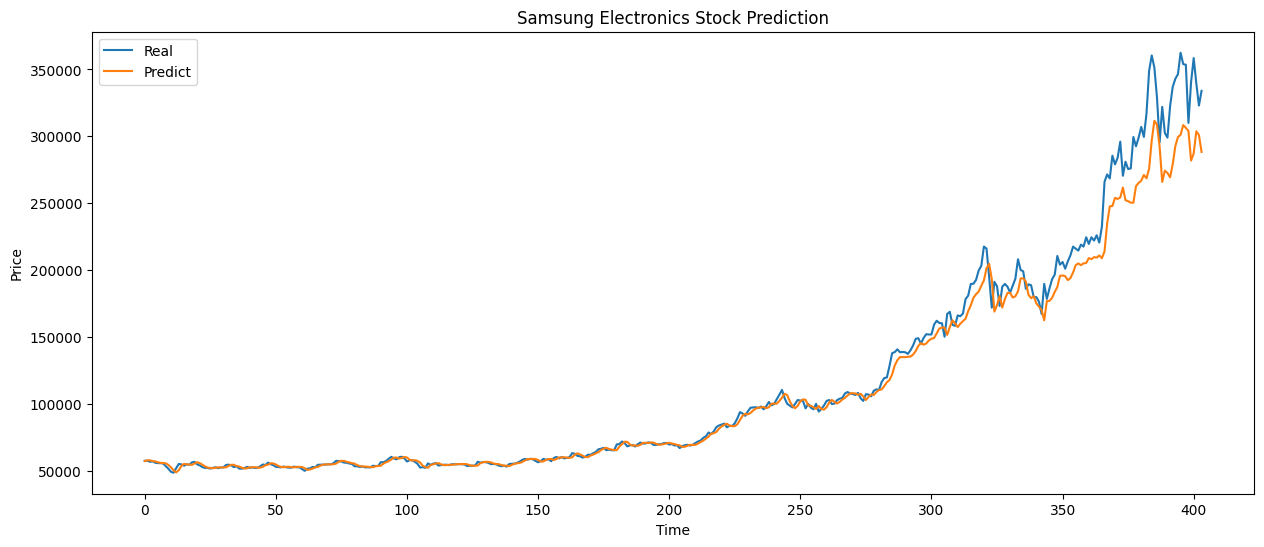

In [52]:
# 시각화 그래프 

plt.figure(figsize=(15,6))

plt.plot(real_price, label="Real")
plt.plot(pred_price, label="Predict")

plt.title("Samsung Electronics Stock Prediction")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()

plt.show()

In [53]:
# 마지막 60일로 내일 에측 

last60 = scaled[-60:]
last60 = last60.reshape(1,60,1)

tomorrow = model.predict(last60)
tomorrow_price = scaler.inverse_transform(tomorrow)

print()
print("="*40)
print("예상 내일 종가")
print(tomorrow_price[0][0])
print("="*40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

예상 내일 종가
287604.75


기존 RNN(Recurrent Neural Network)은 시간이 길어질수록 과거 정보를 잊어버리는 문제
기울기 소실

LSTM (Long Short-Term Meomory) : 장단기 기억 
LSTM은 이 문제를 해결하기 위해 중용한 정보를 오래 기억 (Long-Term Memory)하고, 불필요한 정보는 잊도록(Forget) 설계 

GRU : LSTM 과 성능은 거의 비슷하지만 속도가 빠름 